<a href="https://colab.research.google.com/github/pranchalkumar001/-Diabetes-Prediction-Using-Machine-Learning/blob/main/Diabetes_Prediction_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import kagglehub
uciml_pima_indians_diabetes_database_path = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')

print('Data source import complete.')


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Data source import complete.


# 🏥 Pima Indians Diabetes Prediction - Complete ML Pipeline

## Project Overview
This project implements an end-to-end machine learning solution to predict diabetes in Pima Indian patients using various ML algorithms.

## Objectives
- Perform comprehensive exploratory data analysis
- Build and compare multiple ML models
- Optimize model performance using hyperparameter tuning
- Deploy a production-ready prediction system

## Dataset Information
- **Source:** Pima Indians Diabetes Database (UCI ML Repository)
- **Samples:** 768 patients
- **Features:** 8 medical predictor variables
- **Target:** Diabetes outcome (0/1)

## Technologies Used
- Python 3.x
- Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn
- Machine Learning Algorithms: Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN, Decision Trees, Naive Bayes

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
df = pd.read_csv(r'/kaggle/input/pima-indians-diabetes-database/diabetes.csv')

In [4]:
df.shape

(768, 9)

In [5]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [8]:
print(df['Outcome'].value_counts())
print("\nClass Balance:")
print(df['Outcome'].value_counts(normalize=True) * 100)


Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [9]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
# DATA QUALITY ANALYSIS
# Check for zero values (which are actually missing in this dataset)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n🔍 Zero Values Detection (these represent missing data):")
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    zero_percent = (zero_count / len(df)) * 100
    print(f"{col}: {zero_count} ({zero_percent:.2f}%)")


🔍 Zero Values Detection (these represent missing data):
Glucose: 5 (0.65%)
BloodPressure: 35 (4.56%)
SkinThickness: 227 (29.56%)
Insulin: 374 (48.70%)
BMI: 11 (1.43%)



Correlation with Target Variable:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


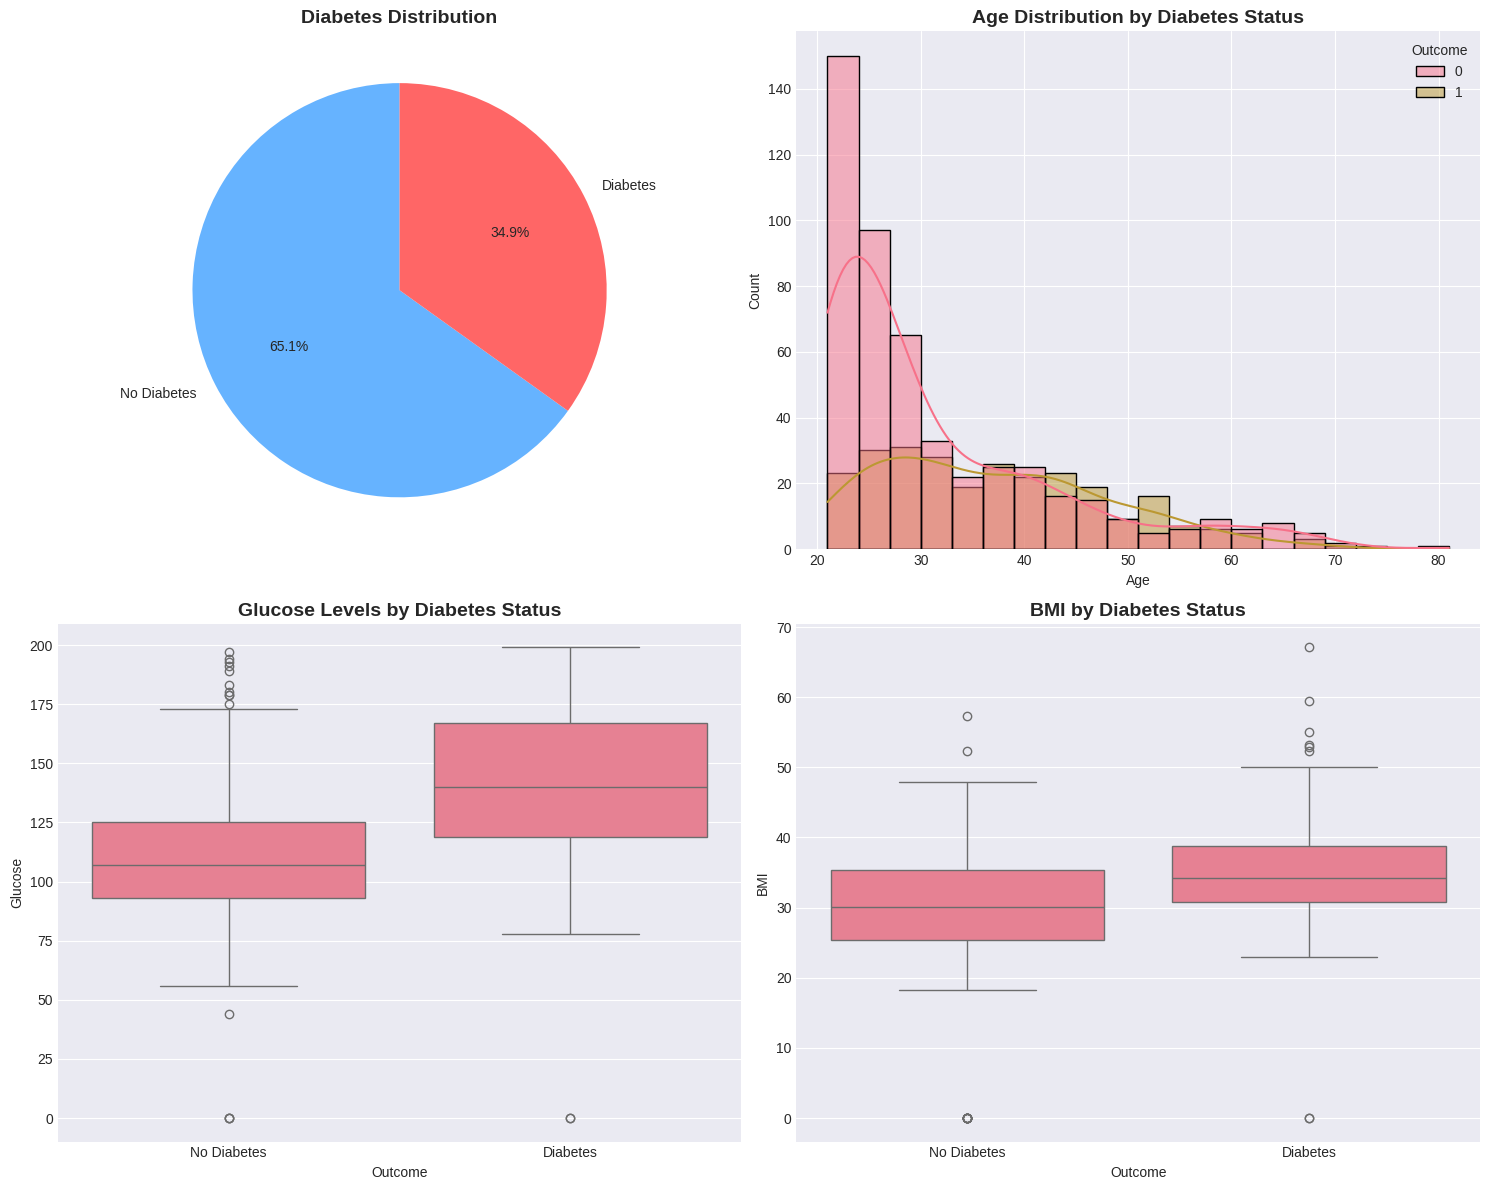

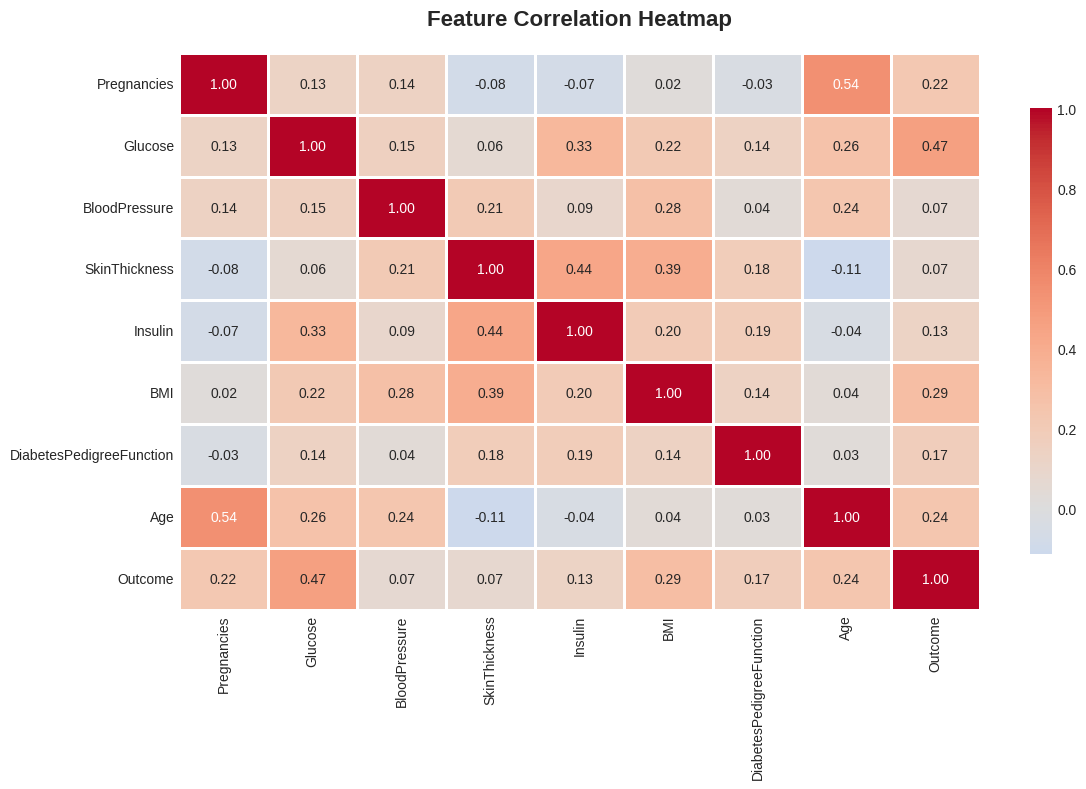

In [11]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Correlation Analysis
print("\nCorrelation with Target Variable:")
correlations = df.corr()['Outcome'].sort_values(ascending=False)
print(correlations)

# Visualization 1: Target Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Target Distribution
axes[0, 0].pie(df['Outcome'].value_counts(), labels=['No Diabetes', 'Diabetes'],
               autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff6666'])
axes[0, 0].set_title('Diabetes Distribution', fontsize=14, fontweight='bold')

# Plot 2: Age Distribution by Outcome
sns.histplot(data=df, x='Age', hue='Outcome', kde=True, ax=axes[0, 1], bins=20)
axes[0, 1].set_title('Age Distribution by Diabetes Status', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age')

# Plot 3: Glucose Distribution by Outcome
sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[1, 0])
axes[1, 0].set_title('Glucose Levels by Diabetes Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(['No Diabetes', 'Diabetes'])

# Plot 4: BMI Distribution by Outcome
sns.boxplot(data=df, x='Outcome', y='BMI', ax=axes[1, 1])
axes[1, 1].set_title('BMI by Diabetes Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# DATA PREPROCESSING
# Create a copy for preprocessing
df_processed = df.copy()

# Replace zeros with median values for specific columns
print("\n🔧 Handling Missing Values (zeros):")
for col in zero_cols:
    median_val = df_processed[df_processed[col] != 0][col].median()
    zero_count = (df_processed[col] == 0).sum()
    df_processed[col] = df_processed[col].replace(0, median_val)
    print(f"✓ Replaced {zero_count} zeros in {col} with median: {median_val:.2f}")
# Feature Engineering: Create new features
print("\n🔬 Feature Engineering:")
df_processed['BMI_Age_Interaction'] = df_processed['BMI'] * df_processed['Age']
df_processed['Glucose_Insulin_Ratio'] = df_processed['Glucose'] / (df_processed['Insulin'] + 1)
df_processed['Age_Group'] = pd.cut(df_processed['Age'], bins=[0, 30, 40, 50, 100],
                                    labels=['Young', 'Middle', 'Senior', 'Elderly'])
df_processed['Age_Group'] = df_processed['Age_Group'].cat.codes

print("✓ Created BMI_Age_Interaction feature")
print("✓ Created Glucose_Insulin_Ratio feature")
print("✓ Created Age_Group feature")

# Prepare features and target
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

print(f"\n✓ Feature Matrix Shape: {X.shape}")
print(f"✓ Target Vector Shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

print(f"\n✓ Training Set: {X_train.shape[0]} samples")
print(f"✓ Testing Set: {X_test.shape[0]} samples")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled using StandardScaler")


🔧 Handling Missing Values (zeros):
✓ Replaced 5 zeros in Glucose with median: 117.00
✓ Replaced 35 zeros in BloodPressure with median: 72.00
✓ Replaced 227 zeros in SkinThickness with median: 29.00
✓ Replaced 374 zeros in Insulin with median: 125.00
✓ Replaced 11 zeros in BMI with median: 32.30

🔬 Feature Engineering:
✓ Created BMI_Age_Interaction feature
✓ Created Glucose_Insulin_Ratio feature
✓ Created Age_Group feature

✓ Feature Matrix Shape: (768, 11)
✓ Target Vector Shape: (768,)

✓ Training Set: 614 samples
✓ Testing Set: 154 samples

✓ Features scaled using StandardScaler



 Training Multiple Models...

✓ Logistic Regression
  Accuracy: 0.7078 | Precision: 0.6000 | Recall: 0.5000 | F1: 0.5455
  Cross-Validation: 0.7721 (+/- 0.0206)

✓ Decision Tree
  Accuracy: 0.7403 | Precision: 0.6458 | Recall: 0.5741 | F1: 0.6078
  Cross-Validation: 0.6955 (+/- 0.0298)

✓ Random Forest
  Accuracy: 0.7468 | Precision: 0.6596 | Recall: 0.5741 | F1: 0.6139
  Cross-Validation: 0.7460 (+/- 0.0249)

✓ Gradient Boosting
  Accuracy: 0.7013 | Precision: 0.5800 | Recall: 0.5370 | F1: 0.5577
  Cross-Validation: 0.7623 (+/- 0.0327)

✓ SVM
  Accuracy: 0.7273 | Precision: 0.6364 | Recall: 0.5185 | F1: 0.5714
  Cross-Validation: 0.7622 (+/- 0.0185)

✓ KNN
  Accuracy: 0.7532 | Precision: 0.6481 | Recall: 0.6481 | F1: 0.6481
  Cross-Validation: 0.7493 (+/- 0.0440)

✓ Naive Bayes
  Accuracy: 0.6948 | Precision: 0.5574 | Recall: 0.6296 | F1: 0.5913
  Cross-Validation: 0.7377 (+/- 0.0148)


 MODEL COMPARISON TABLE:
              Model  Accuracy  Precision   Recall  F1-Score  CV Mean   CV

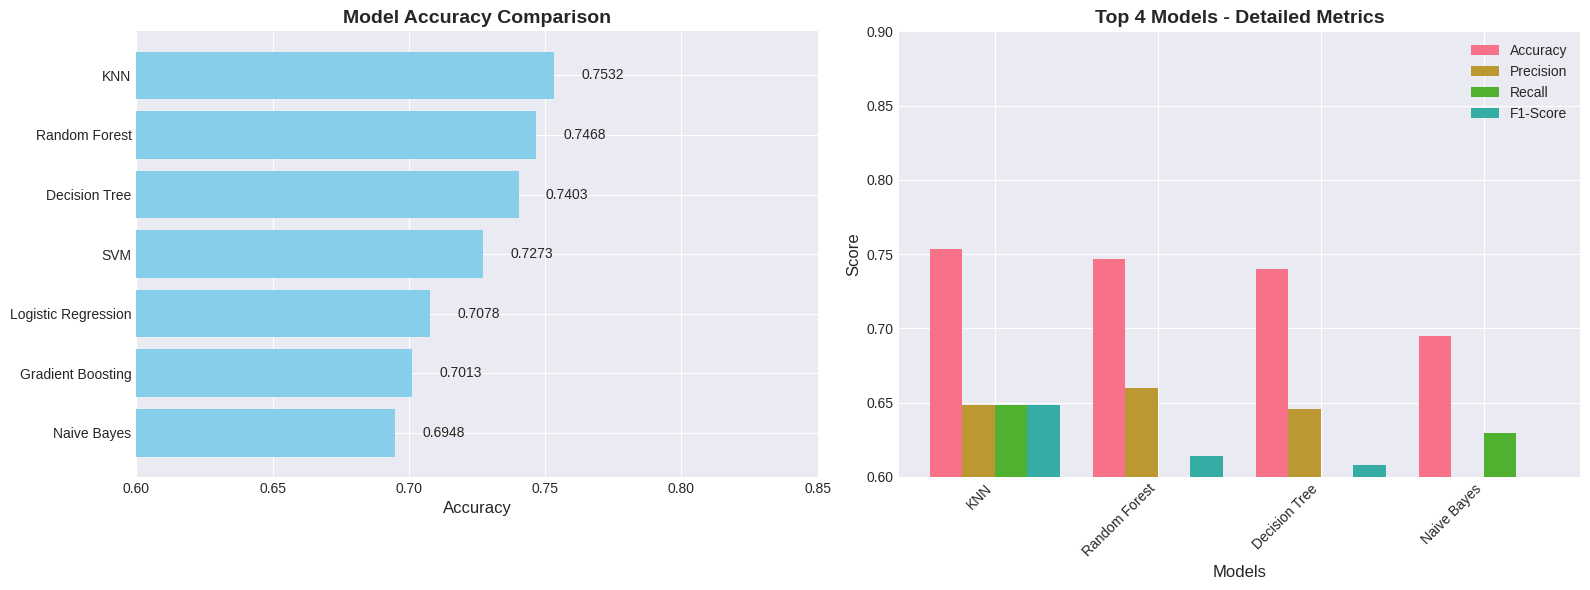

In [13]:
# MODEL TRAINING AND EVALUATION
# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Store results
results = []

print("\n Training Multiple Models...\n")

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

    print(f"✓ {name}")
    print(f"  Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"  Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n MODEL COMPARISON TABLE:")
print(results_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy Comparison
results_df_sorted = results_df.sort_values('Accuracy')
axes[0].barh(results_df_sorted['Model'], results_df_sorted['Accuracy'], color='skyblue')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0.6, 0.85])
for i, v in enumerate(results_df_sorted['Accuracy']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Plot 2: All Metrics Comparison (top 4 models)
top_models = results_df.head(4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(top_models))
width = 0.2

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, top_models[metric], width, label=metric)

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Top 4 Models - Detailed Metrics', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(top_models['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].set_ylim([0.6, 0.9])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# HYPERPARAMETER TUNING (Best Model)
# Select best model (Random Forest typically performs well)
best_model_name = results_df.iloc[0]['Model']
print(f"\nTuning: {best_model_name}")

if 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=42)
elif 'Gradient' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
    base_model = GradientBoostingClassifier(random_state=42)
else:
    param_grid = {
        'C': [0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000)

print("\nStarting Grid Search...")
grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='f1',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Final model
final_model = grid_search.best_estimator_


Tuning: KNN

Starting Grid Search...

✓ Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
✓ Best Cross-Validation F1-Score: 0.6502



 Final Model Performance:
Accuracy:  0.6948
Precision: 0.5745
Recall:    0.5000
F1-Score:  0.5347
ROC-AUC:   0.8135

 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.80      0.77       100
    Diabetes       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



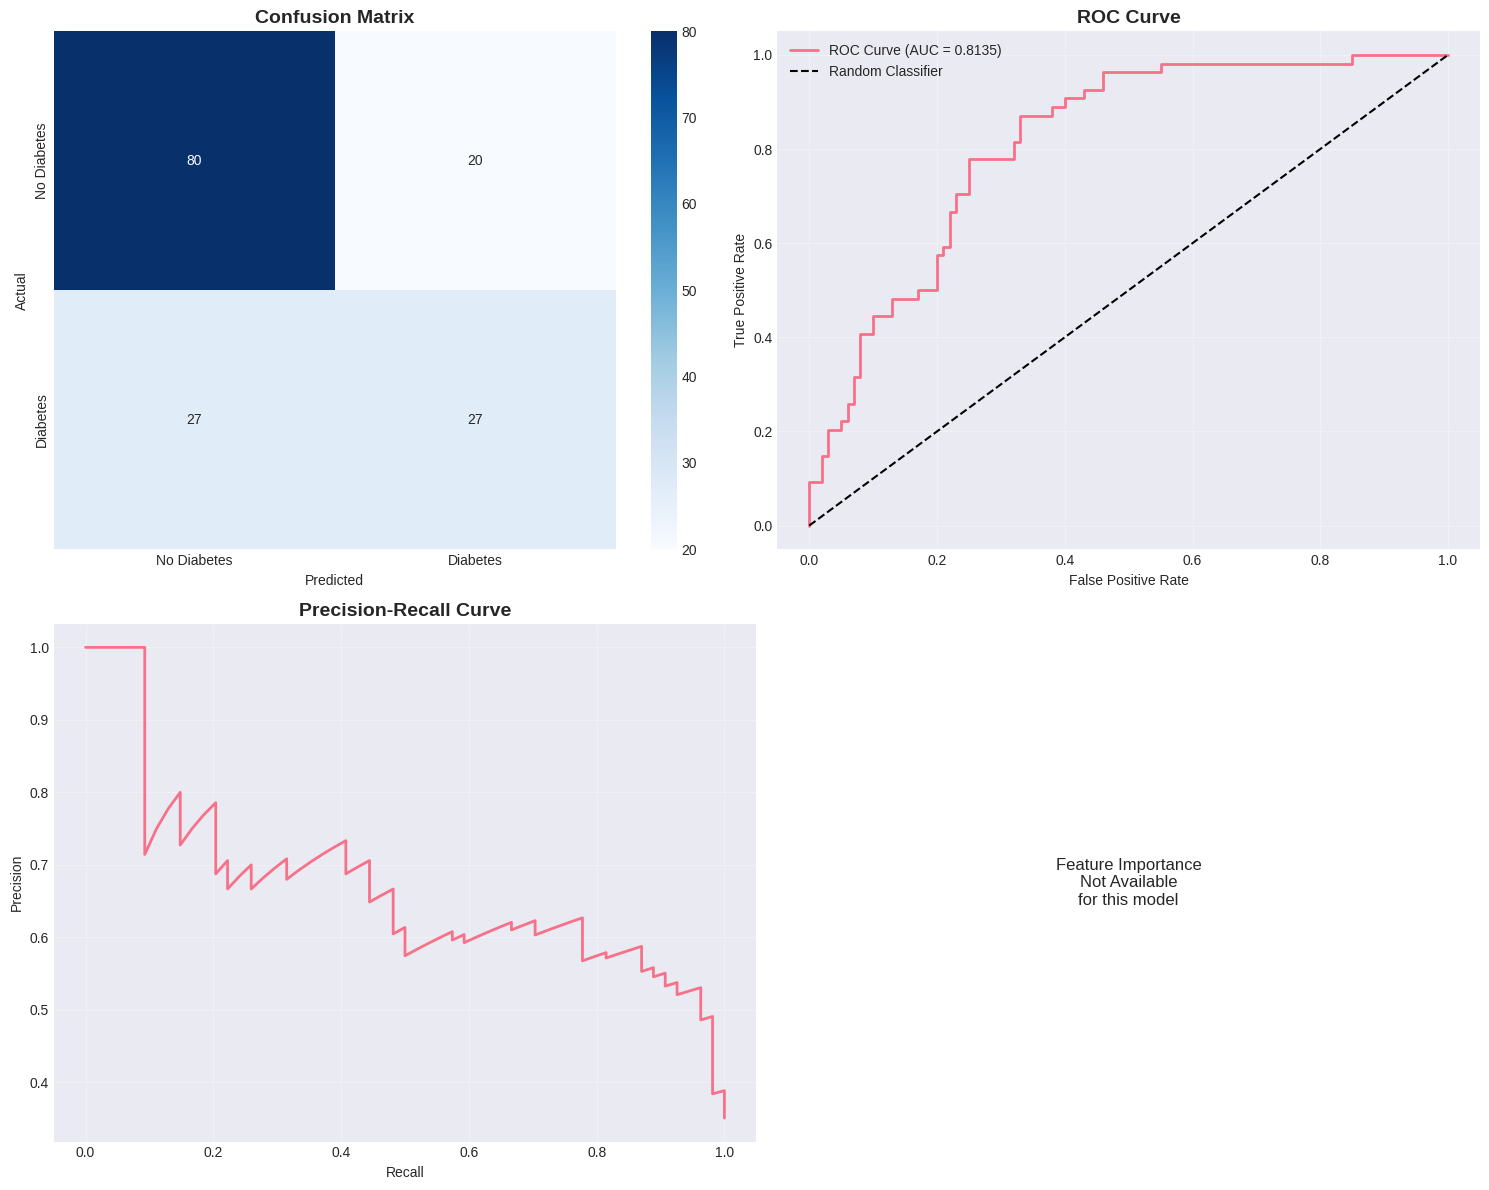

In [15]:
# FINAL MODEL EVALUATION
# Predictions
y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\n Final Model Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_final):.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_final,
                          target_names=['No Diabetes', 'Diabetes']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
auc = roc_auc_score(y_test, y_pred_proba_final)
axes[0, 1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_final)
axes[1, 0].plot(recall_vals, precision_vals, linewidth=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Feature Importance (if available)
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    axes[1, 1].barh(importance_df['Feature'], importance_df['Importance'])
    axes[1, 1].set_xlabel('Importance')
    axes[1, 1].set_title('Feature Importance', fontsize=14, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'Feature Importance\nNot Available\nfor this model',
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_xlim([0, 1])
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('final_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
